<a href="https://colab.research.google.com/github/takwa283/Emotion-Recognition-Project/blob/main/EmotionReco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div class="markdown-google-sans">
  <h1>Bienvenue dans Colab !</h1>
</div>

<div class="markdown-google-sans">
  <h2>&#40;Nouveau&#41; Essayez l'API Gemini</h2>
  <ul>
  <li><a href="https://makersuite.google.com/app/apikey">Generate a Gemini API key</a></li>
  <li><a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Talk_to_Gemini_with_Google%27s_Speech_to_Text_API.ipynb?utm_medium=link&utm_campaign=gemini">Talk to Gemini with the Speech-to-Text API</a></li>
  <li><a href="https://colab.research.google.com/github/google/generative-ai-docs/blob/main/site/en/tutorials/quickstart_colab.ipynb?utm_medium=link&utm_campaign=gemini">Gemini API: Quickstart with Python</a></li>
  <li><a href="https://colab.research.google.com/notebooks/snippets/gemini.ipynb?utm_medium=link&utm_campaign=gemini">Gemini API code sample</a></li>
  <li><a href="https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Learning_with_Gemini_and_ChatGPT.ipynb?utm_medium=link&utm_campaign=gemini">Compare Gemini with ChatGPT</a></li>  
  <li><a href="https://colab.google/notebooks/?utm_medium=link&utm_campaign=gemini">More notebooks</a></li>
  </ul>
</div>


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import shutil
import os

# Créez le dossier 'images' localement (optionnel, shutil.copytree le fait aussi)
os.makedirs('/content/images', exist_ok=True)

# Chemin du dossier source dans Google Drive
source_folder = '/content/drive/My Drive/PFA/KDEF'

# Chemin où vous voulez copier le dossier dans Colab
destination_folder = '/content/images/'

# Copier tout le dossier
shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

# Vérifiez que les fichiers ont été copiés
print("Fichiers copiés dans Colab :")
!ls /content/images/

Fichiers copiés dans Colab :
Angry  Disgust	Fear  Happy  Neutral  Sad  Surprised


In [3]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import cv2
import time
import os

# Importation de TensorFlow et des modules nécessaires pour les modèles
import tensorflow as tf
from keras.applications.densenet import DenseNet121
from keras.applications.vgg16 import VGG16
from keras.applications.inception_v3 import InceptionV3
from keras.applications.mobilenet_v2 import MobileNetV2
from keras.applications.nasnet import NASNetLarge
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from keras.applications.resnet50 import ResNet50
from keras.applications.efficientnet_v2 import EfficientNetV2B3
from keras.applications.efficientnet import EfficientNetB7

# Importation des couches et outils de Keras
from keras.layers import (Dense, GlobalAveragePooling2D, Flatten, BatchNormalization,
                          Input, Average, concatenate, Dropout)
from keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Importation d'un module de sklearn pour la réduction de dimensionnalité
from sklearn.decomposition import PCA


In [ ]:
#!pip install split-folders
#import splitfolders
#input_folder='/content/drive/My Drive/PFA/KDEF'
#splitfolders.ratio(input_folder, output='/content/drive/My Drive/PFA/KDEF1', seed=42, ratio=(0.7,0.3), group_prefix=None)


In [4]:
SIZE=224

In [5]:
train_image = []
train_label = []

for directory_path in glob.glob("/content/drive/My Drive/PFA/KDEF1/train/*"):
    label = directory_path.split("\\")[-1]
    print(label)
    for img_path in glob.glob(os.path.join(directory_path, "*.tiff")):
        print(img_path)
        img = cv2.imread(img_path, cv2.IMREAD_COLOR)
        img = cv2.resize(img, (SIZE, SIZE))
        img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
        train_image.append(img)
        train_label.append(label)
train_image = np.array(train_image)
train_label = np.array(train_label)

/content/drive/My Drive/PFA/KDEF1/train/Neutral
/content/drive/My Drive/PFA/KDEF1/train/Surprised
/content/drive/My Drive/PFA/KDEF1/train/Sad
/content/drive/My Drive/PFA/KDEF1/train/Angry
/content/drive/My Drive/PFA/KDEF1/train/Disgust
/content/drive/My Drive/PFA/KDEF1/train/Happy
/content/drive/My Drive/PFA/KDEF1/train/Fear


In [6]:
input_size = (SIZE, SIZE)  # Define input_size as a tuple


In [7]:
# Define the model
model = Sequential() #Crée un modèle séquentiel dans lequel les couches sont empilées les unes après les autres.
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy']) #Configure le modèle pour l'entraînement.

# set up data generators for train, test, and validation sets
#permet de prétraiter les images avant de les envoyer au modèle.

train_datagen =ImageDataGenerator(rescale=1./255)

test_datagen =ImageDataGenerator(rescale=1./255) #Normalise les valeurs des pixels entre 0 et 1 (au lieu de 0-255)

train_generator =train_datagen.flow_from_directory(
   '/content/drive/MyDrive/PFA/KDEF1/train',

    target_size=input_size,

    batch_size=32,

    class_mode='categorical')

test_generator= test_datagen.flow_from_directory(

    '/content/drive/MyDrive/PFA/KDEF1/val',

    target_size=input_size,

    batch_size=32,

    class_mode='categorical', shuffle=False)

Found 343 images belonging to 7 classes.
Found 147 images belonging to 7 classes.


Si vous connaissez déjà Colab, regardez cette vidéo pour découvrir les tables interactives, l'affichage de l'historique du code exécuté et la palette de commandes.

<center>
  <a href="https://www.youtube.com/watch?v=rNgswRZ2C1Y" target="_blank">
  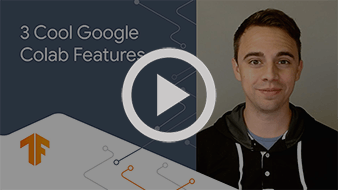
  </a>
</center>

In [8]:
base_model=tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(224,224,3)
)
base_model.trainable=False

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
inputs= tf.keras.Input(shape=(224,224,3)) #input
 #prétraiter les images avant de les envoyer au modèle pré-entraîné.
x =tf.keras.applications.vgg16.preprocess_input(inputs)
x=base_model(inputs,training=False)
flatten = Flatten()
x=flatten(x)
#x=tf.keras.layers.GlobalAveragePooling2D()(x)
x=tf.keras.layers.Dropout(0.5)(x)
x=tf.keras.layers.Dense(90)(x) #Couche Dense (90 neurones)
outputs=tf.keras.layers.Dense(7,activation="softmax")(x) #Couche Dense de sortie (7 neurones + activation Softmax)
model=tf.keras.Model(inputs,outputs)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ vgg16 (Functional)                   │ (None, 7, 7, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 90)                  │       2,258,010 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 7)                   │             637 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 16,973,335 (64.75 MB)

 Trainable params: 2,258,647 (8.62 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 224, 224, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 224, 224, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 112, 112, 128)       │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 112, 112, 128)       │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 56, 56, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 56, 56, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 28, 28, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 28, 28, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 14, 14, 512)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 14, 14, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 7, 7, 512)           │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [10]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history_VGG16=model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=10,
    validation_data=test_generator,
    validation_steps=len(test_generator)
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 332s 30s/step - accuracy: 0.1906 - loss: 12.1668 - val_accuracy: 0.4014 - val_loss: 10.1016
Epoch 2/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 356s 29s/step - accuracy: 0.4805 - loss: 7.6618 - val_accuracy: 0.5510 - val_loss: 3.0902
Epoch 3/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 320s 28s/step - accuracy: 0.6567 - loss: 2.1366 - val_accuracy: 0.6463 - val_loss: 1.5153
Epoch 4/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 302s 28s/step - accuracy: 0.7861 - loss: 0.9431 - val_accuracy: 0.7619 - val_loss: 0.7961
Epoch 5/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 352s 33s/step - accuracy: 0.8801 - loss: 0.3056 - val_accuracy: 0.8435 - val_loss: 0.4489
Epoch 6/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 300s 28s/step - accuracy: 0.9117 - loss: 0.1981 - val_accuracy: 0.8707 - val_loss: 0.4082
Epoch 7/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 304s 28s/step - accuracy: 0.9753 - loss: 0.0788 - val_accuracy: 0.8367 - val_loss: 0.5842
Epoch 8/10
11/11 ━━━━━━━━━━━━━━━━━━━━ 302s 28s/step - accuracy: 0.9686 - loss: 0.1110 - val_accuracy: 

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Charger une image de test (remplacez par le chemin de votre image)
img_path = "/content/drive/MyDrive/PFA/KDEF1/val/Angry/F02AN.jpg"

# Charger et redimensionner l'image
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

# Vérifier la prédiction
predictions = model.predict(img_array)
print("Résultat du modèle :", predictions)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Résultat du modèle : [[3.4708738e-25 0.0000000e+00 0.0000000e+00 1.0000000e+00 0.0000000e+00
  7.4895776e-21 0.0000000e+00]]


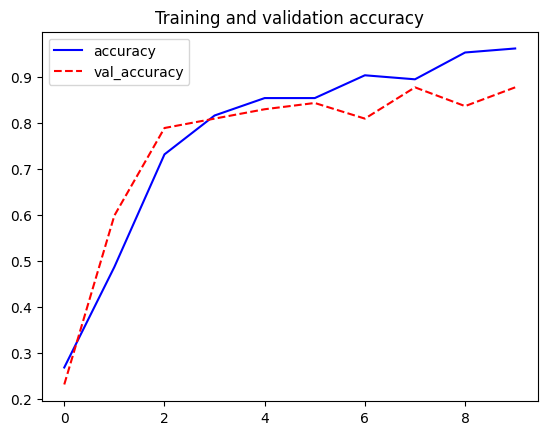

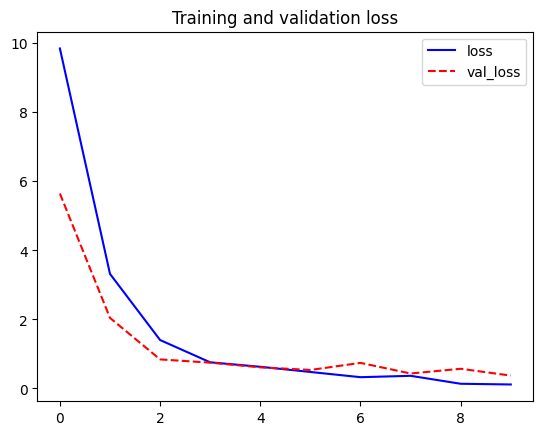

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

acc=history_VGG16.history['accuracy']
val_acc=history_VGG16.history['val_accuracy']
loss=history_VGG16.history['loss']
val_loss=history_VGG16.history['val_loss']
epochs=range(len(acc))
plt.plot(epochs,acc,'-b',label='accuracy')
plt.plot(epochs,val_acc,'--r',label='val_accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs,loss,'-b',label='loss')
plt.plot(epochs,val_loss,'--r',label='val_loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()


5/5 ━━━━━━━━━━━━━━━━━━━━ 95s 18s/step


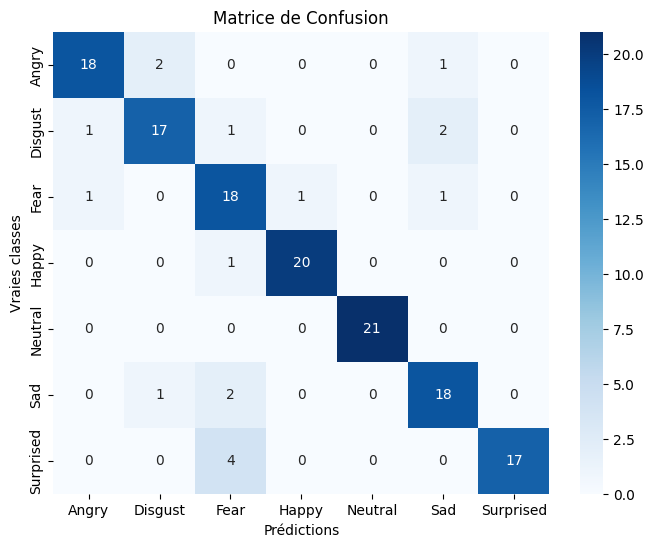

              precision    recall  f1-score   support

       Angry       0.90      0.86      0.88        21
     Disgust       0.85      0.81      0.83        21
        Fear       0.69      0.86      0.77        21
       Happy       0.95      0.95      0.95        21
     Neutral       1.00      1.00      1.00        21
         Sad       0.82      0.86      0.84        21
   Surprised       1.00      0.81      0.89        21

    accuracy                           0.88       147
   macro avg       0.89      0.88      0.88       147
weighted avg       0.89      0.88      0.88       147



In [ ]:
#Afficher la matrice de confusion
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Prédictions du modèle
y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convertir en classes prédites

# Vraies étiquettes des données de test
y_true = test_generator.classes

# Générer la matrice de confusion
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# Afficher la matrice de confusion sous forme de heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=test_generator.class_indices, yticklabels=test_generator.class_indices)
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de Confusion")
plt.show()

# Afficher un rapport détaillé des performances du modèle
print(classification_report(y_true, y_pred_classes, target_names=test_generator.class_indices))

In [ ]:
model.save('my_model.keras')

In [ ]:
from google.colab import files

# Pour le modèle .h5
files.download('my_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ✅ Installer Anvil Uplink si ce n'est pas encore fait
!pip install anvil-uplink

import anvil.server
import tensorflow as tf
import numpy as np
from PIL import Image
import io

# ✅ Clé Uplink de ton projet Anvil (À récupérer dans Settings > Uplink)
UPLINK_KEY = "server_J36WUDS55SZGKF4HHYEUERSP-ZGNZO2QZBUWGMMMT"

# ✅ Connexion à Anvil
try:
    anvil.server.connect(UPLINK_KEY)
    print("✅ Connexion réussie à Anvil Uplink !")
except Exception as e:
    print(f"❌ Erreur de connexion à Anvil : {e}")
    exit(1)

print("🔄 Chargement du modèle...")
model = tf.keras.models.load_model("/content/drive/MyDrive/visage.h5")  # Charge le modèle entraîné
print("✅ Modèle chargé avec succès !")


class_labels = ["Angry", "Disgust", "Fear", "Happy", "Neutral", "Sad", "Surprise"]


# ✅ Fonction de prédiction accessible via Anvil
@anvil.server.callable
def predict_emotion(image_file):
    try:
        print("📥 Réception de l'image depuis Anvil...")
        img = Image.open(io.BytesIO(image_file.get_bytes())).convert("RGB")
        img = img.resize((224, 224))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        print("🔍 Prédiction en cours...")
        prediction = model.predict(img_array)
        predicted_class = int(np.argmax(prediction))  # Numéro de la classe
        emotion = class_labels[predicted_class]  # Nom de la classe

        print(f"🎯 Emotion prédite : {emotion} ({predicted_class})")
        return emotion  # Retourne le nom de la classe

    except Exception as e:
        print(f"❌ Erreur lors de la prédiction : {e}")
        return f"❌ Erreur lors de la prédiction : {str(e)}"


# ✅ Attendre les requêtes Anvil
print("🔄 Serveur en attente des requêtes...")
anvil.server.wait_forever()


  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


Connecting to wss://anvil.works/uplink
Anvil websocket open
Connected to "Default Environment" as SERVER
✅ Connexion réussie à Anvil Uplink !
🔄 Chargement du modèle...


✅ Modèle chargé avec succès !
🔄 Serveur en attente des requêtes...
📥 Réception de l'image depuis Anvil...
🔍 Prédiction en cours...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
🎯 Emotion prédite : Surprise (6)


KeyboardInterrupt: 

<div class="markdown-google-sans">
  <h2>Qu'est-ce que Colab ?</h2>
</div>

Colab &#40;ou "Colaboratory"&#41; vous permet d'écrire et d'exécuter du code Python dans votre navigateur avec
- Aucune configuration requise
- Accès sans frais aux GPU
- Partage facile

Que vous soyez <strong>étudiant</strong>, <strong>data scientist</strong> ou <strong>chercheur en IA</strong>, Colab peut vous simplifier la tâche. Regardez la <a href="https://www.youtube.com/watch?v=inN8seMm7UI">présentation de Colab</a> pour en savoir plus ou commencez tout de suite.

<div class="markdown-google-sans">

## <strong>Premiers pas</strong>
</div>

Le document que vous consultez n'est pas une page Web statique, mais un environnement interactif appelé <strong>notebook Colab</strong>, qui vous permet d'écrire et d'exécuter du code.

Voici par exemple une <strong>cellule de code</strong> avec un bref script en Python qui calcule une valeur, l'enregistre dans une variable et imprime le résultat :

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

Pour exécuter le code dans la cellule ci-dessus, sélectionnez-le en cliquant dessus, puis cliquez sur le bouton de lecture à gauche du code ou utilisez le raccourci clavier Commande/Ctrl+Entrée. Pour modifier le code, cliquez simplement sur la cellule.

Les variables que vous définissez dans une cellule peuvent être utilisées par la suite dans d'autres cellules :

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

Les notebooks Colab vous permettent d'utiliser, dans un même document, du <strong>code exécutable</strong>, du <strong>texte enrichi</strong>, des <strong>images</strong>, du code <strong>HTML</strong>, du code <strong>LaTeX</strong> et bien plus. Lorsque vous créez des notebooks Colab, ils sont enregistrés dans votre compte Google Drive. Vous pouvez facilement les partager avec vos collaborateurs ou vos amis, qui peuvent alors y apporter des commentaires ou même les modifier. Pour en savoir plus, consultez la page <a href="/notebooks/basic_features_overview.ipynb">Présentation de Colaboratory</a>. Pour créer un notebook Colab, utilisez le menu "Fichier" ci-dessus ou le lien <a href="http://colab.research.google.com#create=true">Créer un notebook Colab</a>.

Les notebooks Colab sont des notebooks Jupyter hébergés par Colab. Pour en savoir plus sur le projet Jupyter, consultez le site Web <a href="https://www.jupyter.org">jupyter.org</a>.

<div class="markdown-google-sans">

## Science des données
</div>

Colab vous permet de tirer pleinement parti des bibliothèques populaires Python pour analyser et visualiser des données. La cellule de code ci-dessous utilise <strong>numpy</strong> pour générer des données aléatoires et <strong>matplotlib</strong> pour les visualiser. Pour modifier le code, cliquez simplement sur la cellule.

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Vous pouvez importer vos propres données dans les notebooks Colab depuis votre compte Google Drive, y compris depuis des feuilles de calcul, ainsi que depuis GitHub et de nombreuses autres sources. Pour en savoir plus sur l'importation de données et l'utilisation de Colab dans le domaine de la science des données, consultez les liens ci-dessous dans la section <a href="#working-with-data">Utiliser les données</a>.

<div class="markdown-google-sans">

## Machine learning
</div>

Colab vous permet d'importer un ensemble de données d'images, d'entraîner un classificateur d'images sur cet ensemble et d'évaluer le modèle, tout cela avec <a href="https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb">quelques lignes de code</a>. Les notebooks Colab exécutent ce code sur les serveurs cloud de Google. Vous avez donc à votre disposition toute la puissance du matériel Google, y compris les <a href="#using-accelerated-hardware">GPU et TPU</a>, quelle que soit la puissance de votre ordinateur. Vous n'avez besoin que d'un navigateur.

Colab est très largement utilisé par la communauté du machine learning, par exemple dans les applications suivantes :
- Premiers pas avec TensorFlow
- Développement et entraînement de réseaux de neurones
- Expérimentation avec les TPU
- Dissémination de la recherche en IA
- Création de tutoriels

Pour voir comment les notebooks Colab sont utilisés dans des applications de machine learning, reportez-vous aux <a href="#machine-learning-examples">exemples de machine learning</a> ci-dessous.

<div class="markdown-google-sans">

## Autres ressources

### Utiliser les notebooks dans Colab

</div>

- [Présentation de Colaboratory](/notebooks/basic_features_overview.ipynb)
- [Guide de Markdown](/notebooks/markdown_guide.ipynb)
- [Importer des bibliothèques et installer des dépendances](/notebooks/snippets/importing_libraries.ipynb)
- [Enregistrer et charger des notebooks dans GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Formulaires interactifs](/notebooks/forms.ipynb)
- [Widgets interactifs](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Utiliser les données
</div>

- [Chargement de données : Drive, Sheets et Google Cloud Storage](/notebooks/io.ipynb)
- [Graphiques : visualiser les données](/notebooks/charts.ipynb)
- [Premiers pas avec BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Cours d'initiation au Machine Learning

<div>

Vous trouverez ci-dessous quelques-uns des notebooks de la formation Google en ligne sur le machine learning. Consultez la <a href="https://developers.google.com/machine-learning/crash-course/">formation complète en ligne</a> pour en savoir plus.
- [Présentation du DataFrame pandas](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Régression linéaire avec tf.keras et des données synthétiques](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Utiliser le matériel accéléré
</div>

- [TensorFlow avec des GPU](/notebooks/gpu.ipynb)
- [TensorFlow avec des TPU](/notebooks/tpu.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Exemples

</div>

- <a href="https://colab.research.google.com/github/NVIDIA/NeMo/blob/stable/tutorials/VoiceSwapSample.ipynb">Échange de voix avec NeMo</a> : utilisez le kit Nvidia NeMo pour l'IA conversationnelle afin d'échanger une voix dans un fragment audio contre une voix générée par ordinateur.

- <a href="https://tensorflow.org/hub/tutorials/tf2_image_retraining">Recyclage d'un classificateur d'images</a> : construisez un modèle Keras sur un classificateur d'images pré-entraîné pour faire la distinction entre différentes fleurs.
- <a href="https://tensorflow.org/hub/tutorials/tf2_text_classification">Classification de texte</a> : classez des avis sur des films provenant de la base de données IMDB comme <em>positifs</em> ou <em>négatifs</em>.
- <a href="https://tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization">Transfert de style</a> : utilisez le deep learning pour transférer un style d'une image à une autre.
- <a href="https://tensorflow.org/hub/tutorials/retrieval_with_tf_hub_universal_encoder_qa">Questions/Réponses sur l'encodeur de phrases universel multilingue</a> : utilisez un modèle de machine learning afin de répondre aux questions issues de l'ensemble de données SQuAD.
- <a href="https://tensorflow.org/hub/tutorials/tweening_conv3d">Interpolation vidéo</a> : prédisez ce qui s'est passé entre la première et la dernière image d'une vidéo.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
import shutil
import os

# Créez le dossier 'images' localement (optionnel, shutil.copytree le fait aussi)
os.makedirs('/content/images', exist_ok=True)

# Chemin du dossier source dans Google Drive
source_folder = '/content/drive/My Drive/PFA/KDEF'

# Chemin où vous voulez copier le dossier dans Colab
destination_folder = '/content/images/'

# Copier tout le dossier
shutil.copytree(source_folder, destination_folder, dirs_exist_ok=True)

# Vérifiez que les fichiers ont été copiés
print("Fichiers copiés dans Colab :")
!ls /content/images/

In [ ]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import cv2
import time
import os

# Importation de TensorFlow et des modules nécessaires pour les modèles
import tensorflow as tf
from keras.applications.densenet import DenseNet121
from keras.applications.vgg16 import VGG16
from keras.applications.inception_v3 import InceptionV3
from keras.applications.mobilenet_v2 import MobileNetV2
from keras.applications.nasnet import NASNetLarge
from keras.applications.inception_resnet_v2 import InceptionResNetV2
from keras.applications.resnet50 import ResNet50
from keras.applications.efficientnet_v2 import EfficientNetV2B3
from keras.applications.efficientnet import EfficientNetB7

# Importation des couches et outils de Keras
from keras.layers import (Dense, GlobalAveragePooling2D, Flatten, BatchNormalization,
                          Input, Average, concatenate, Dropout)
from keras.models import Model, Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

# Importation d'un module de sklearn pour la réduction de dimensionnalité
from sklearn.decomposition import PCA